In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [28]:
data_path = Path("/Users/patrykksiazek/Desktop/Machine-Learning---Preliminary-Data-Analysis/Data Preparation and Analysis/")

In [29]:
grouped_train_logs = pd.read_csv(data_path / "grouped_train_logs.csv")
X_train_scores = pd.read_csv(data_path / "X_train_scores.csv")
X_test_scores = pd.read_csv(data_path / "X_test_scores.csv")

In [30]:
grouped_train_logs

,id,words_per_essay,max_up_time,min_down_time,event_per_essay,writing_duration,chars_per_essay,chars_per_minute,total_pauses,total_pause_time,...,removes_per_essay,removes_len_per_essay,nonproduction_per_essay,nonproduction_len_per_essay,replaces_per_essay,replaces_len_per_essay,pastes_per_essay,pastes_len_per_essay,removes_per_words,replaces_per_words
0,001519c8,255,1801969,4526,2557,1797443,2010,67.095313,1500200.0,1500200.0,...,417.0,417.0,120,0,7.0,107.0,0.0,0.0,1.635294,0.027451
1,0022f953,320,1788969,30623,2454,1758346,1938,66.130329,1482955.0,1482955.0,...,260.0,260.0,254,0,1.0,11.0,1.0,2.0,0.812500,0.003125
2,0042269b,404,1771669,4441,4136,1767228,3515,119.339440,1346027.0,1346027.0,...,439.0,632.0,175,0,7.0,338.0,0.0,0.0,1.086634,0.017327
3,0059420b,206,1404469,41395,1556,1363074,1304,57.399672,1173478.0,1173478.0,...,151.0,151.0,99,0,1.0,17.0,1.0,12.0,0.733010,0.004854
4,0075873a,252,1662472,78470,2531,1584002,1942,73.560513,1270300.0,1270300.0,...,517.0,517.0,72,0,0.0,0.0,0.0,0.0,2.051587,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2466,ffb8c745,273,1791649,22467,4739,1769182,3588,121.683354,1269512.0,1269512.0,...,960.0,962.0,189,0,2.0,1004.0,0.0,0.0,3.516484,0.007326
2467,ffbef7e5,438,1799174,21732,2604,1777442,2395,80.846520,1563221.0,1563221.0,...,60.0,60.0,148,0,1.0,6.0,0.0,0.0,0.136986,0.002283
2468,ffccd6fd,201,1959363,23482,3063,1935881,2849,88.300882,1704301.0,1704301.0,...,88.0,88.0,126,0,0.0,0.0,0.0,0.0,0.437811,0.000000
2469,ffec5b38,413,1508504,19885,3242,1488619,2895,116.685330,1199180.0,1199180.0,...,276.0,343.0,71,0,0.0,0.0,0.0,0.0,0.668281,0.000000


In [31]:
cols_to_drop = ['Unnamed: 0', 'id', 'max_up_time', 'min_down_time', 'nonproduction_len_per_essay']

In [32]:
train_data = grouped_train_logs.merge(X_train_scores, on="id").drop(columns=cols_to_drop)
test_data = grouped_train_logs.merge(X_test_scores, on="id").drop(columns=cols_to_drop)

In [33]:
train_data

,words_per_essay,event_per_essay,writing_duration,chars_per_essay,chars_per_minute,total_pauses,total_pause_time,perc_pause_time,pauses_per_words,removes_per_essay,removes_len_per_essay,nonproduction_per_essay,replaces_per_essay,replaces_len_per_essay,pastes_per_essay,pastes_len_per_essay,removes_per_words,replaces_per_words,score
0,320,2454,1758346,1938,66.130329,1482955.0,1482955.0,0.843381,4634.234375,260.0,260.0,254,1.0,11.0,1.0,2.0,0.812500,0.003125,3.5
1,404,4136,1767228,3515,119.339440,1346027.0,1346027.0,0.761660,3331.750000,439.0,632.0,175,7.0,338.0,0.0,0.0,1.086634,0.017327,6.0
2,206,1556,1363074,1304,57.399672,1173478.0,1173478.0,0.860906,5696.495146,151.0,151.0,99,1.0,17.0,1.0,12.0,0.733010,0.004854,2.0
3,252,2531,1584002,1942,73.560513,1270300.0,1270300.0,0.801956,5040.873016,517.0,517.0,72,0.0,0.0,0.0,0.0,2.051587,0.000000,4.0
4,275,2211,1736280,1794,61.994609,1556295.0,1556295.0,0.896339,5659.254545,338.0,341.0,76,3.0,25.0,0.0,0.0,1.229091,0.010909,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1971,273,4739,1769182,3588,121.683354,1269512.0,1269512.0,0.717570,4650.227106,960.0,962.0,189,2.0,1004.0,0.0,0.0,3.516484,0.007326,3.5
1972,438,2604,1777442,2395,80.846520,1563221.0,1563221.0,0.879478,3568.997717,60.0,60.0,148,1.0,6.0,0.0,0.0,0.136986,0.002283,4.0
1973,201,3063,1935881,2849,88.300882,1704301.0,1704301.0,0.880375,8479.109453,88.0,88.0,126,0.0,0.0,0.0,0.0,0.437811,0.000000,1.5
1974,413,3242,1488619,2895,116.685330,1199180.0,1199180.0,0.805565,2903.583535,276.0,343.0,71,0.0,0.0,0.0,0.0,0.668281,0.000000,5.0


In [34]:
X_train = train_data.drop(columns= ['score'])
y_train = train_data['score']
X_test = test_data.drop(columns= ['score'])
y_test = test_data['score']

# Benchmark - Constant Value

In [35]:
dummy_regressor = DummyRegressor(strategy = 'mean')
dummy_regressor.fit(X_train, y_train)


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [36]:
y_test_pred_dummy = dummy_regressor.predict(X_test)

In [37]:
y_test_pred_dummy[0]

np.float64(3.7115384615384617)

In [38]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_dummy))


In [39]:
rmse_test

np.float64(1.026074718912257)

In [40]:
dummy_variance = np.var(y_test_pred_dummy - y_test)

In [43]:
dummy_variance = np.var(y_test_pred_dummy - y_test)
dummy_bias = np.mean(y_test_pred_dummy) - np.mean(y_test)

In [45]:
dummy_variance, dummy_bias

(np.float64(1.0528272625242323), np.float64(0.0014374514374502212))

# Linear Regression

In [55]:
def train_and_evaluate(model, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test):

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    return rmse_train, rmse_test

In [56]:
train_and_evaluate(dummy_regressor)[:2]

(np.float64(1.0243930075638994), np.float64(1.026074718912257))

In [57]:
model = LinearRegression()

In [58]:
results = train_and_evaluate(model)

In [59]:
results[:2]

(np.float64(0.7222265874865683), np.float64(0.7391203361917981))

In [60]:
coef = model.coef_

In [61]:
intercept = model.intercept_
intercept

np.float64(7.174803907188554)

Text(0, 0.5, 'Wartość Współczynnika')

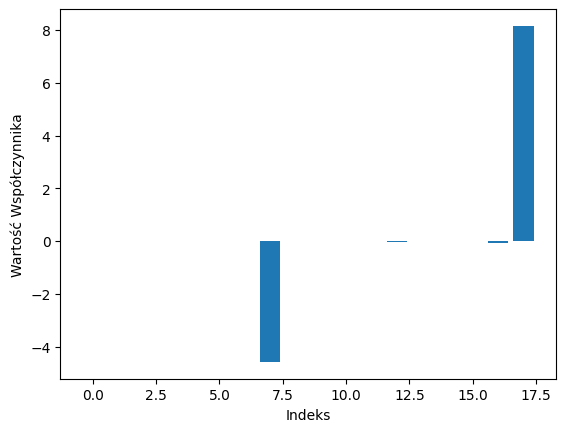

In [62]:
plt.bar(range(len(coef)), coef)
plt.xlabel("Indeks")
plt.ylabel("Wartość Współczynnika")

In [64]:
scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [ ]:
results = train_and_evaluate(X_train_normalized, X_test_normalized)